In [19]:
# # Install scikit-rf if not already available
# %pip install scikit-rf matplotlib

In [20]:
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import shutil
import re
from datetime import datetime

In [21]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _run_suffix(path: Path) -> str:
    """Extract run token e.g. '-0001' from a stem, even when followed by '-parameter'.

    Matches the last -NNN... that is followed by either a non-digit suffix or end-of-stem.
      MWS-sweep-02-0001.s2p          → '-0001'
      MWS-sweep-02-0001-parameter.txt → '-0001'
      04232026_145355-0001.s2p        → '-0001'
    """
    m = re.search(r'(-\d+)(?=-\D|$)', path.stem)
    return m.group(1) if m else ''

def _archive_file(src: Path, dest_dir: Path) -> Path:
    mtime = datetime.fromtimestamp(src.stat().st_mtime)
    dest  = dest_dir / f'{mtime.strftime("%m%d%Y_%H%M%S")}{_run_suffix(src)}{src.suffix}'
    shutil.copy2(src, dest)
    return dest

def _find_matching_txt(s2p: Path, txt_files: list) -> Path | None:
    """Find the txt file whose run suffix matches the given s2p file."""
    suffix = _run_suffix(s2p)
    for txt in txt_files:
        if _run_suffix(txt) == suffix:
            return txt
    return None

def _read_pressure(s2p_path: Path) -> float | None:
    """Find the archived .txt with matching run suffix and extract number after '='.

    Archived s2p: '04232026_145355-0001.s2p'
    Archived txt: '04232026_145355-0001.txt'
    File content:  'Pressure=375'
    """
    suffix      = _run_suffix(s2p_path)
    txt_matches = list(s2p_path.parent.glob(f'*{suffix}.txt'))
    if not txt_matches:
        return None
    text = txt_matches[0].read_text(errors='ignore').strip()
    if '=' not in text:
        return None
    m = re.search(r'[+-]?[\d.]+(?:[eE][+-]?\d+)?', text.split('=', 1)[1])
    return float(m.group()) if m else None

In [22]:
folder   = 'TOUCHSTONE files'
run_name = 'Scooter_Curved_Anode_Sim1'
# run_name='Scooter_Curved_Anode_Solid_Sim2'
touchstone_dir = Path(r'C:\Users\vpodolsky_avalanche\Desktop\CST Local Files\Cloud Results\Scooter_Curved_Anode_Sim1_run2_nofield_mon_Results', folder)
# touchstone_dir = Path(r'C:\Users\vpodolsky_avalanche\Desktop\CST Local Files\Cloud Results\Scooter_Curved_Anode_Solid_Sim2_Results', folder)


# project_dir = touchstone_dir.parents[1]
print(project_dir)
dest_dir    = project_dir / 'RESULTS_TO_PROCESS' / f'{folder} {run_name}'
dest_dir.mkdir(parents=True, exist_ok=True)

# --- Differential archive — only copy run suffixes not yet in dest_dir ---
archived_suffixes = {_run_suffix(f) for f in dest_dir.glob('*.s2p')}
source_s2p        = sorted(touchstone_dir.glob('*.s2p'))
source_txt        = sorted(touchstone_dir.glob('*.txt'))

missing = [f for f in source_s2p if _run_suffix(f) not in archived_suffixes]

if not missing:
    print(f'Archive up to date ({len(archived_suffixes)} run(s)).\n  {dest_dir}')
else:
    to_archive = []
    for s2p in missing:
        to_archive.append(s2p)
        txt = _find_matching_txt(s2p, source_txt)
        if txt:
            to_archive.append(txt)

    print(f'Archiving {len(missing)} new run(s) to:\n  {dest_dir}\n')
    for f in to_archive:
        dest = _archive_file(f, dest_dir)
        print(f'  {f.name:<40}  →  {dest.name}')

    for f in to_archive:
        f.unlink()
    print(f'\nDeleted {len(to_archive)} original(s) from:\n  {touchstone_dir}')

s2p_files = sorted(dest_dir.glob('*.s2p'))
print(f'\nUsing {len(s2p_files)} S2P file(s):')
for f in s2p_files:
    print(f'  {f.name}')

C:\Users\vpodolsky_avalanche\Desktop\CST Local Files\Cloud Results
Archive up to date (7 run(s)).
  C:\Users\vpodolsky_avalanche\Desktop\CST Local Files\Cloud Results\RESULTS_TO_PROCESS\TOUCHSTONE files Scooter_Curved_Anode_Sim1

Using 7 S2P file(s):
  04242026_023341-0001.s2p
  04242026_061959-0002.s2p
  04242026_100507-0003.s2p
  04242026_135246-0004.s2p
  04242026_174847-0005.s2p
  04242026_213535-0006.s2p
  04252026_012053-0007.s2p


In [35]:
swept_pressures = [_read_pressure(f) for f in s2p_files]
print(swept_pressures)
print(f'Pressures extracted from .txt files:')
for f, p in zip(s2p_files, swept_pressures):
    tag = f'{p:.4g} Torr' if p is not None else 'pressure unknown'
    print(f'  {f.name}  →  {tag}')

baseline_idx = next((i for i, p in enumerate(swept_pressures) if p == 0), 0)
pressures    = [p for p in swept_pressures if p is not None and p != 0]

print(f'\nbaseline_idx = {baseline_idx}  (pressure = {swept_pressures[baseline_idx]} Torr)')
print(f'Non-zero pressures: {pressures}')

[0.0, 1.0, 10.0, 100.0, 300.0, 500.0, 750.0]
Pressures extracted from .txt files:
  04242026_023341-0001.s2p  →  0 Torr
  04242026_061959-0002.s2p  →  1 Torr
  04242026_100507-0003.s2p  →  10 Torr
  04242026_135246-0004.s2p  →  100 Torr
  04242026_174847-0005.s2p  →  300 Torr
  04242026_213535-0006.s2p  →  500 Torr
  04252026_012053-0007.s2p  →  750 Torr

baseline_idx = 0  (pressure = 0.0 Torr)
Non-zero pressures: [1.0, 10.0, 100.0, 300.0, 500.0, 750.0]


In [24]:
networks = [rf.Network(str(f)) for f in s2p_files]
ntwk = networks[0]
print(f'Network: {ntwk.name}')
print(f'Frequency range: {ntwk.f[0]/1e9:.3f} – {ntwk.f[-1]/1e9:.3f} GHz  ({len(ntwk.f)} points)')
print(f'Number of ports: {ntwk.nports}')

Network: 04242026_023341-0001
Frequency range: 59.000 – 67.000 GHz  (1001 points)
Number of ports: 2


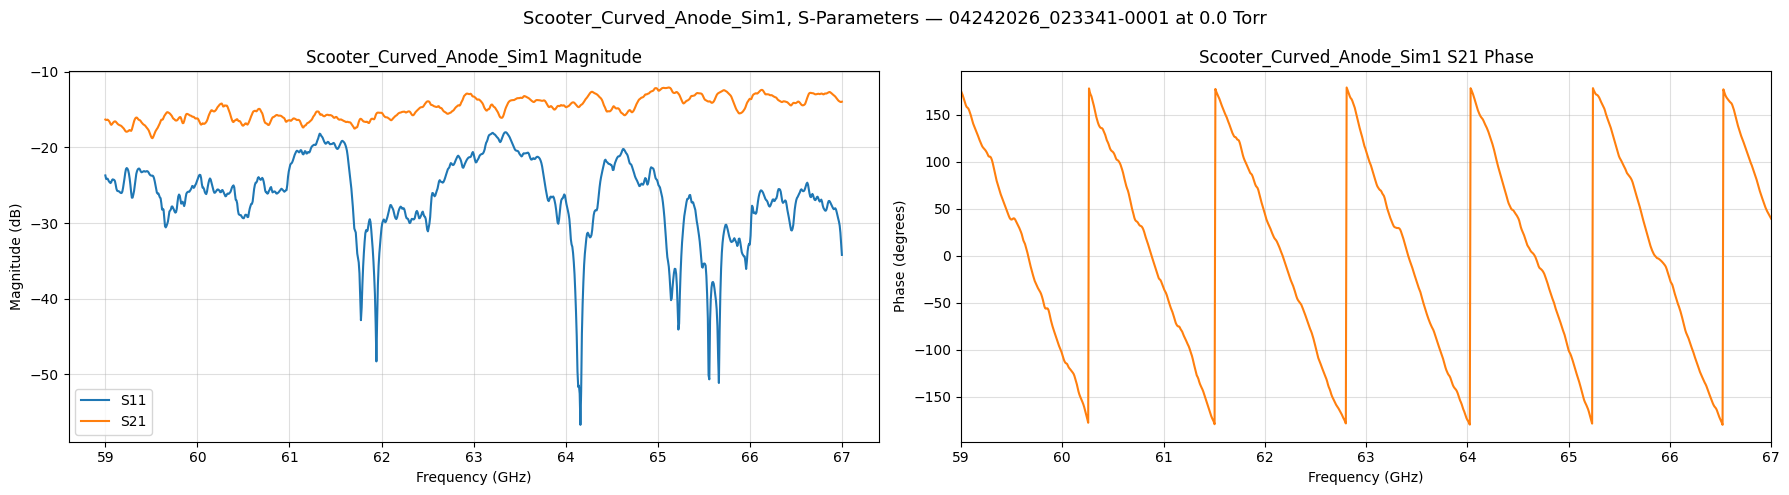

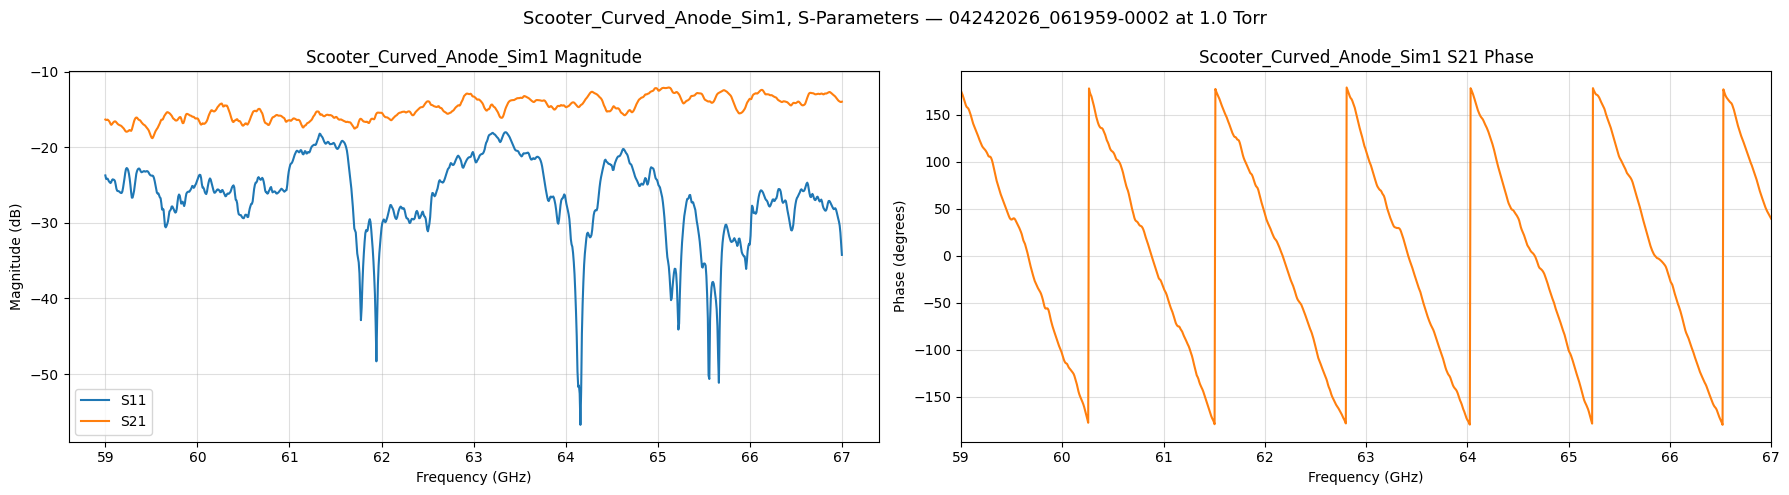

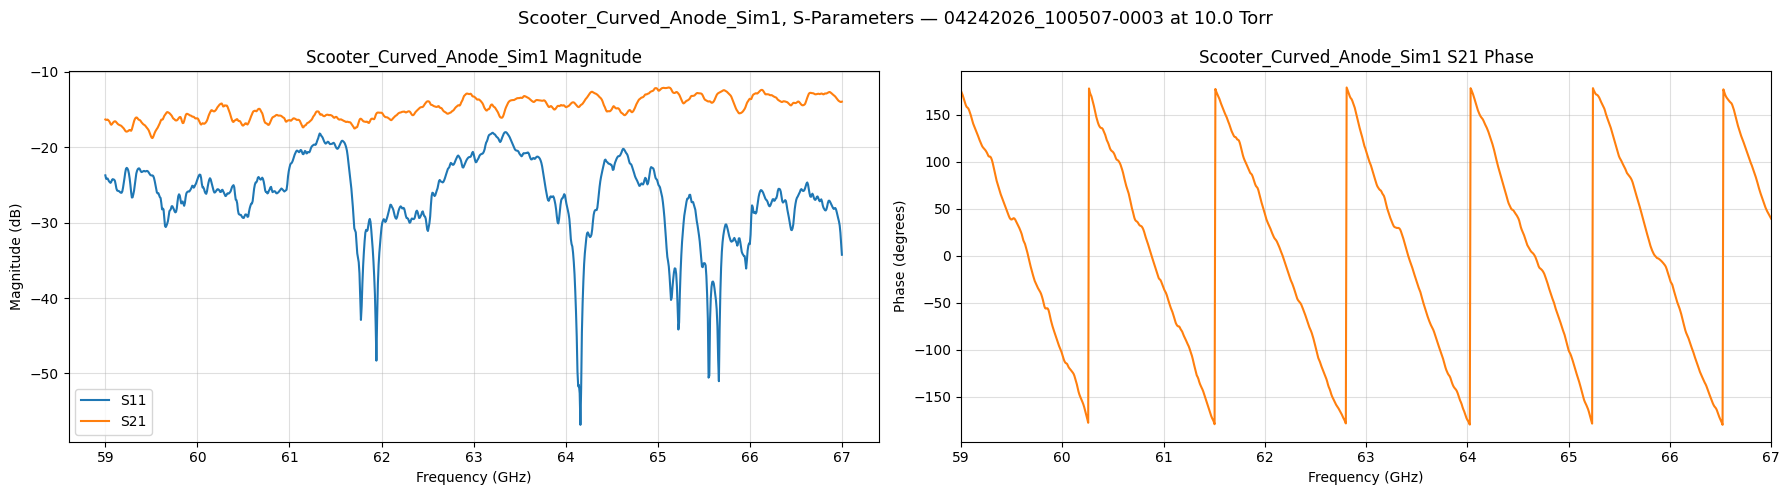

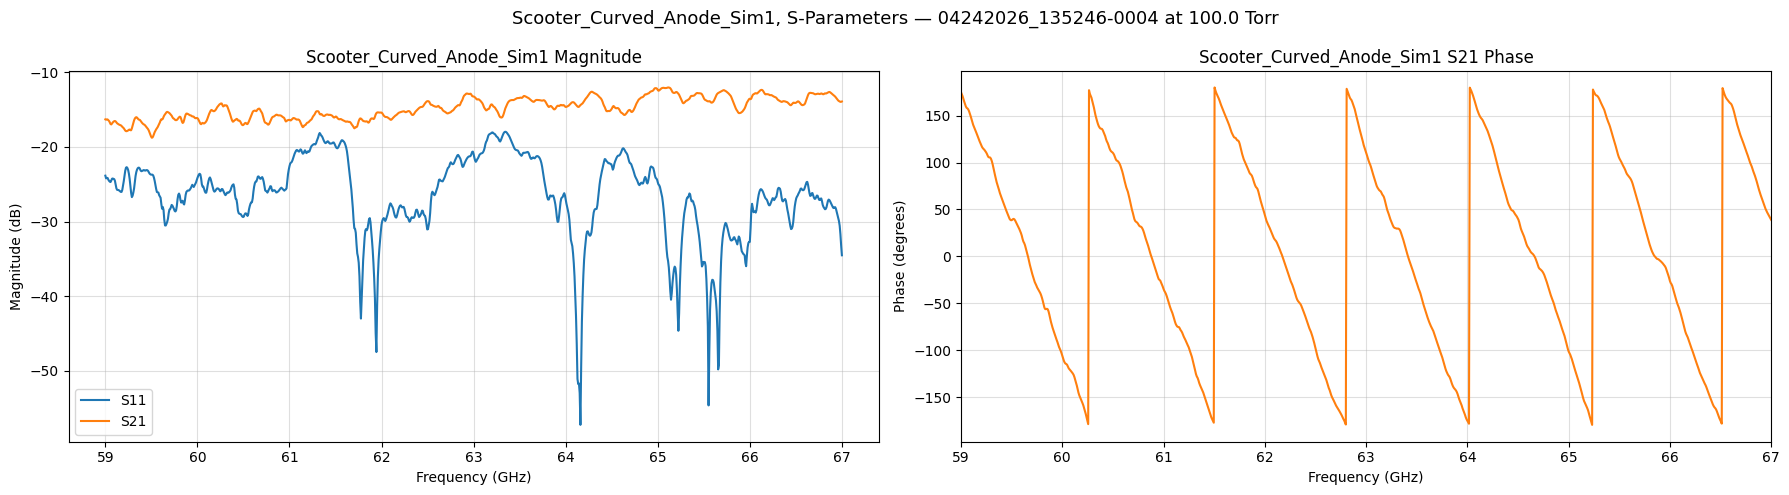

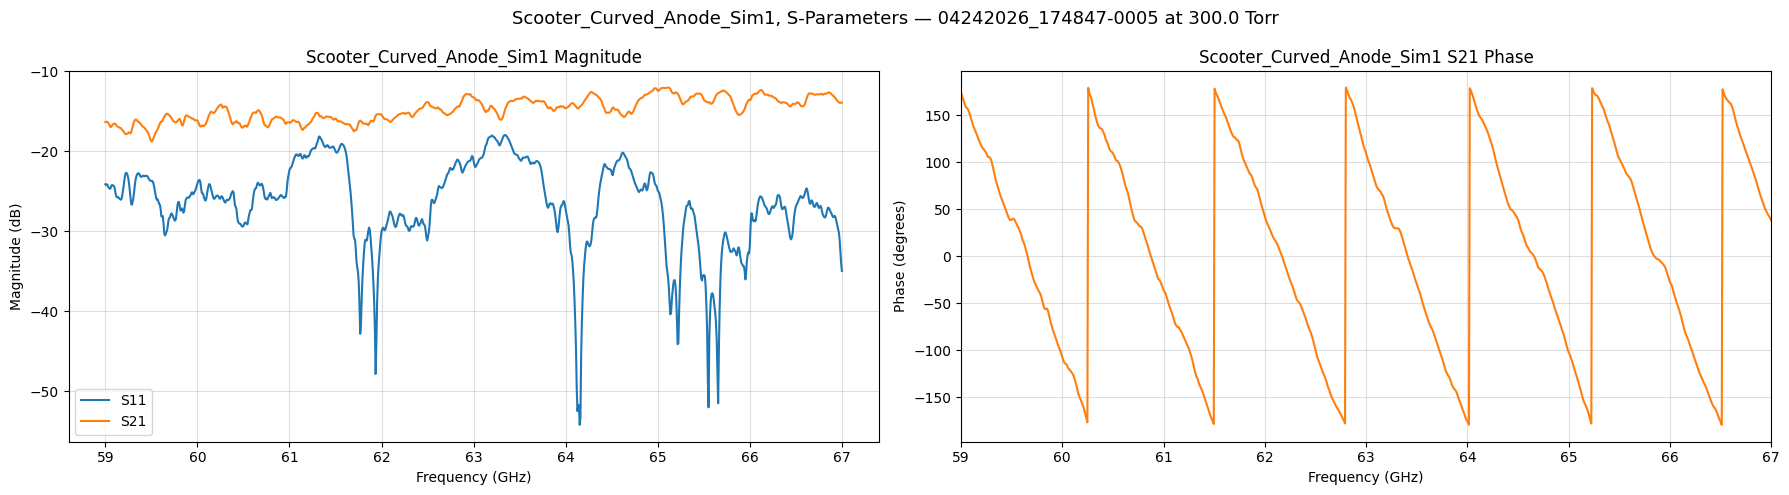

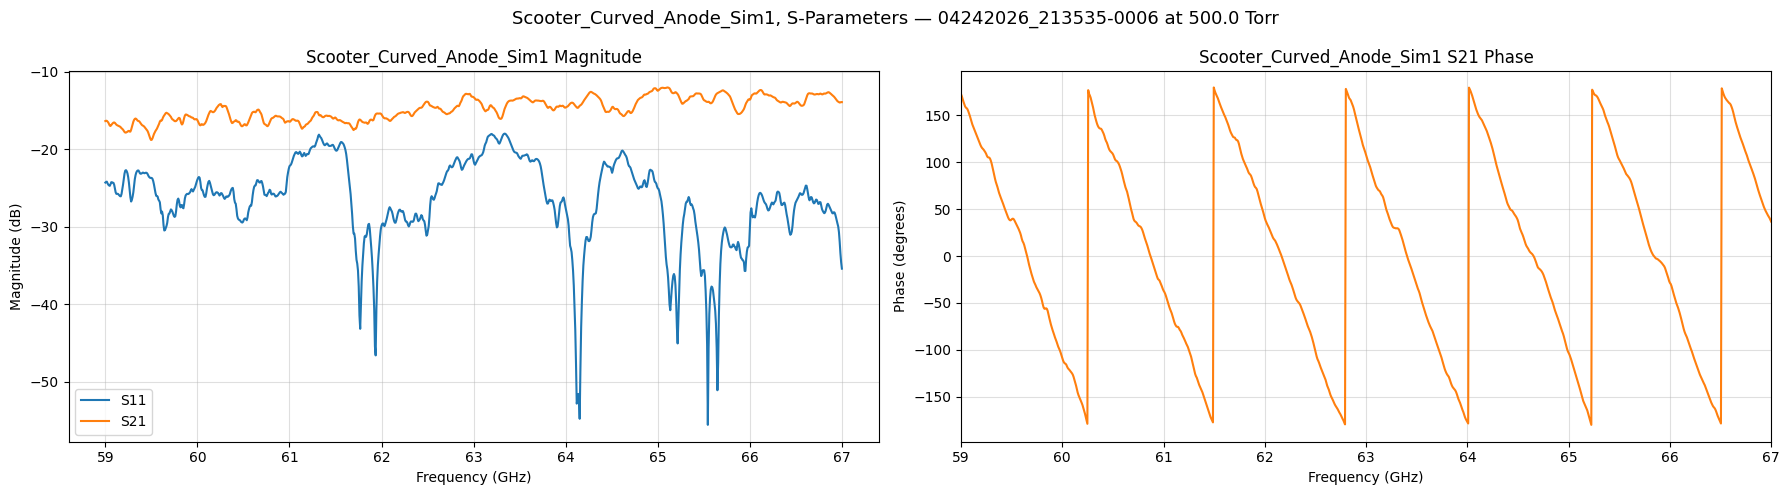

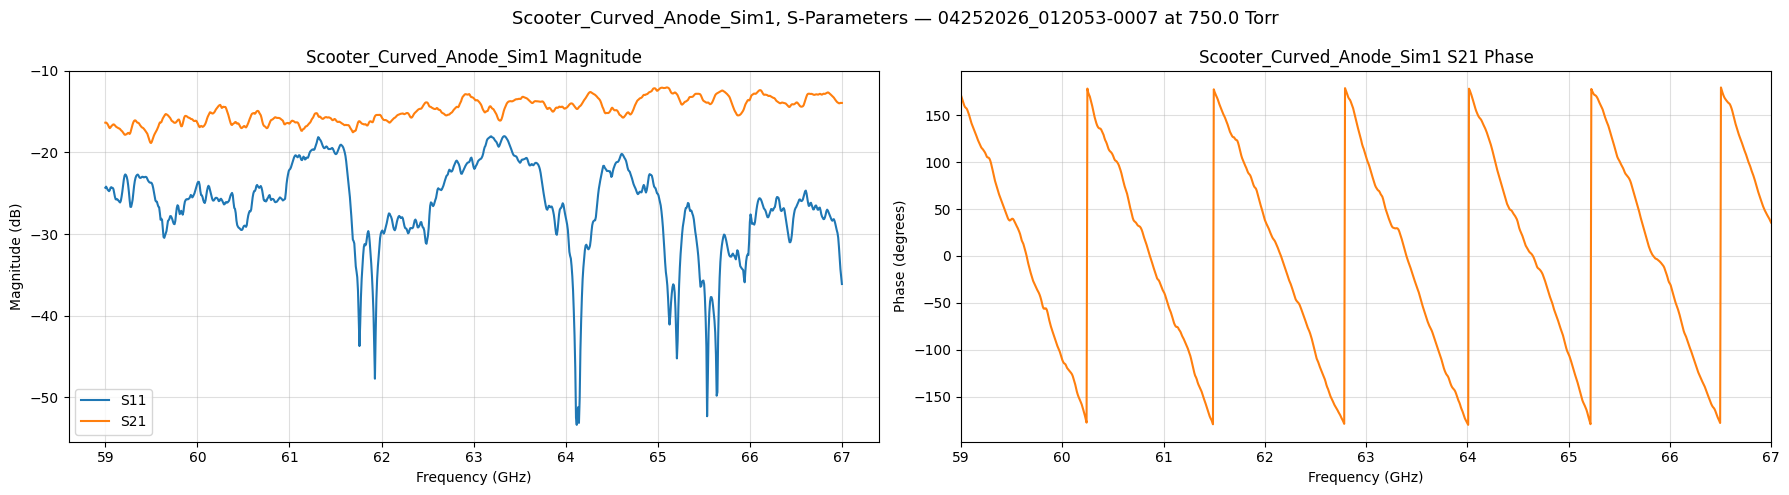

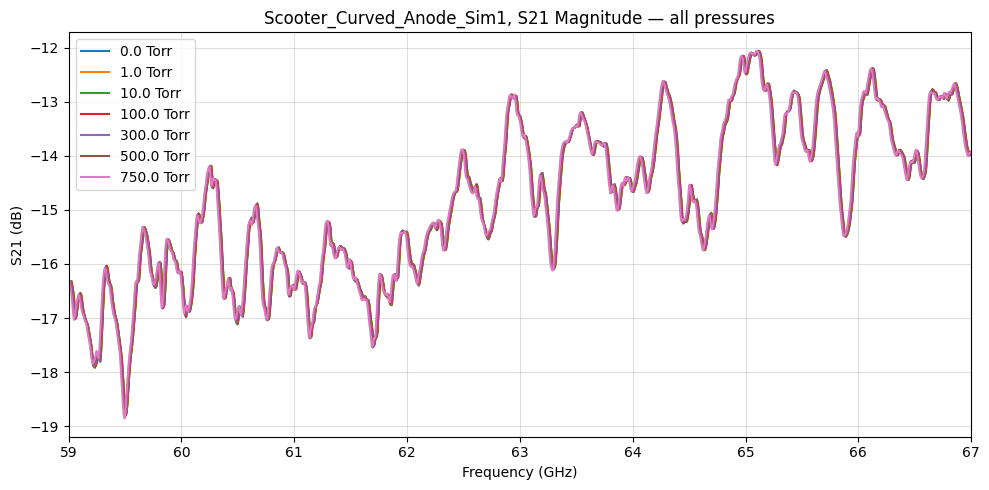

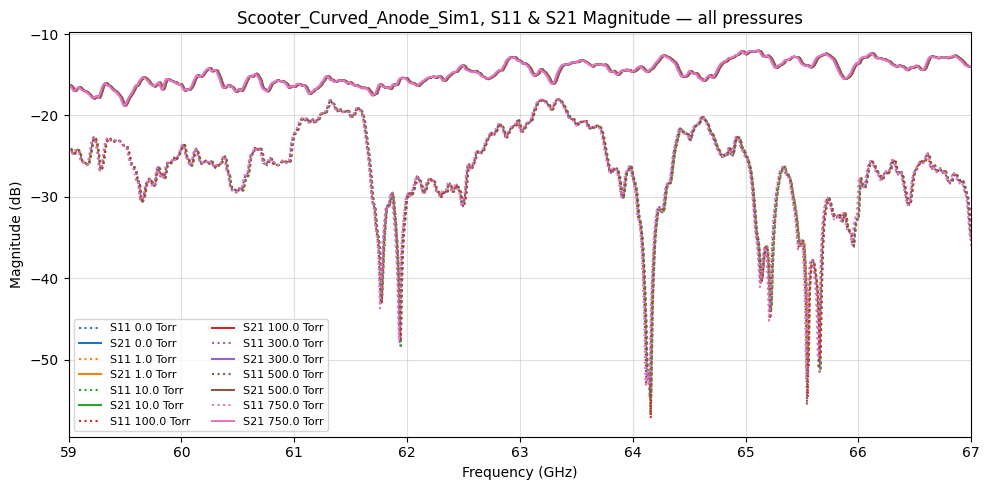

In [25]:
# S11 → index (0,0), S21 → index (1,0)
params = {'S11': (0, 0), 'S21': (1, 0)}

cmap=plt.cm.tab10
colors=[cmap(i) for i,_ in enumerate(networks)]
for idx, ntwk in enumerate(networks):
    freq_ghz = ntwk.f / 1e9

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f'{run_name}, S-Parameters — {ntwk.name} at {swept_pressures[idx]} Torr', fontsize=13)

    # --- Magnitude (dB): S11 and S21 overlaid ---
    ax = axes[0]
    for label, (i, j) in params.items():
        mag_db = 20 * np.log10(np.abs(ntwk.s[:, i, j]) + 1e-30)
        ax.plot(freq_ghz, mag_db, label=label)
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(f'{run_name} Magnitude')
    ax.legend()
    ax.grid(True, alpha=0.4)

    # --- Phase: S21 ---
    ax = axes[1]
    i, j = params['S21']
    ax.plot(freq_ghz, np.angle(ntwk.s[:, i, j], deg=True), color='tab:orange')
    ax.set_xlim([min(freq_ghz),max(freq_ghz)])
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Phase (degrees)')
    ax.set_title(f'{run_name} S21 Phase')
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

# --- S21 magnitude zoom: all pressures overlaid ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.set_title(f'{run_name}, S21 Magnitude — all pressures')
i, j = params['S21']
for idx, ntwk in enumerate(networks):
    mag_db = 20 * np.log10(np.abs(ntwk.s[:, i, j]) + 1e-30)
    ax2.plot(ntwk.f / 1e9, mag_db, color=colors[idx], label=f'{swept_pressures[idx]} Torr')
ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel('S21 (dB)')
ax2.legend()
ax2.grid(True, alpha=0.4)
# ax2.set_ylim(-1, 1)
ax2.set_xlim([min(freq_ghz),max(freq_ghz)])
plt.tight_layout()
plt.show()

# --- S11 and S21 all pressures on one plot ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.set_title(f'{run_name}, S11 & S21 Magnitude — all pressures')
for idx, ntwk in enumerate(networks):
    freq = ntwk.f / 1e9
    for label, (i, j) in params.items():
        mag_db = 20 * np.log10(np.abs(ntwk.s[:, i, j]) + 1e-30)
        ls = '-' if label == 'S21' else ':'
        ax3.plot(freq, mag_db, color=colors[idx], linestyle=ls,
                 label=f'{label} {swept_pressures[idx]} Torr')
ax3.set_xlabel('Frequency (GHz)')
ax3.set_ylabel('Magnitude (dB)')
ax3.set_xlim([min(freq_ghz),max(freq_ghz)])
ax3.legend(ncol=2, fontsize=8)
ax3.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

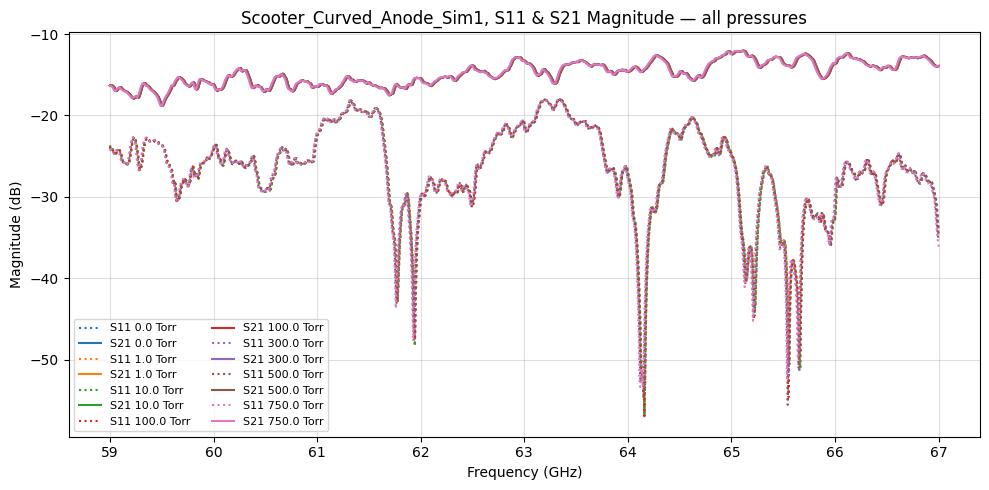

In [26]:
# --- S11 and S21 all pressures on one plot ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.set_title(f'{run_name}, S11 & S21 Magnitude — all pressures')
for idx, ntwk in enumerate(networks):
    freq = ntwk.f / 1e9
    for label, (i, j) in params.items():
        mag_db = 20 * np.log10(np.abs(ntwk.s[:, i, j]) + 1e-30)
        ls = '-' if label == 'S21' else ':'
        ax3.plot(freq, mag_db, color=colors[idx], linestyle=ls,
                 label=f'{label} {swept_pressures[idx]} Torr')
ax3.set_xlabel('Frequency (GHz)')
ax3.set_ylabel('Magnitude (dB)')
# ax3.set_xlim([min(freq_ghz),max(freq_ghz)])
ax3.legend(ncol=2, fontsize=8)
ax3.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

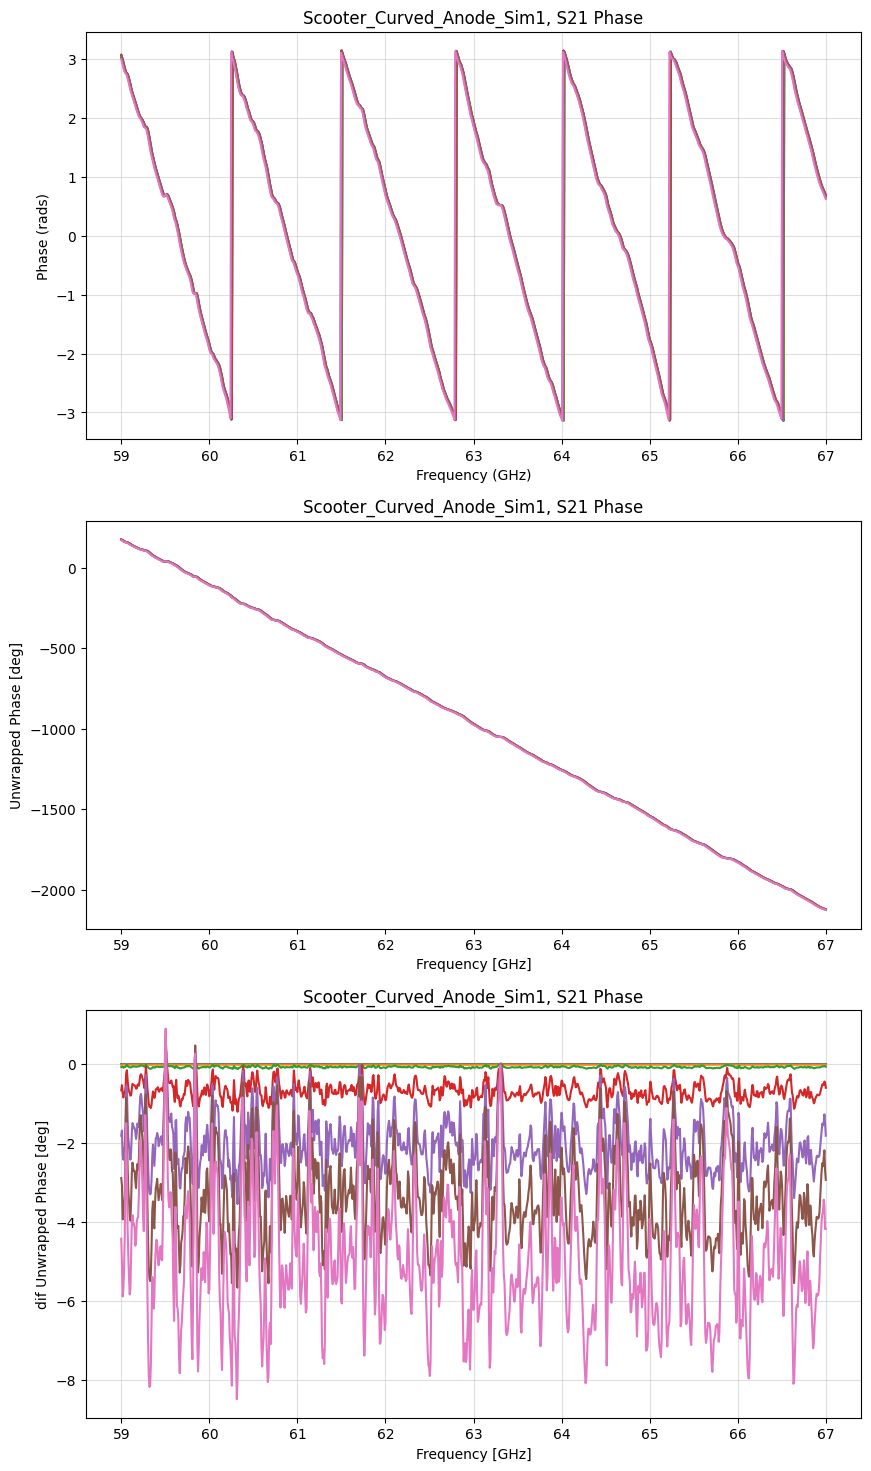

In [27]:
# --- Phase: S21 ---

fig,axes=plt.subplots(3,1,figsize=(10,18))
i, j = params['S21']
cmap=plt.cm.tab10
colors=[cmap(i) for i,_ in enumerate(networks)]
phase_0=np.unwrap(np.angle(networks[0].s[:, i, j]))*180/np.pi

for ii,ntwk in enumerate(networks):
    ax=axes[0]
    ax.plot(freq_ghz, np.angle(ntwk.s[:, i, j]), color=colors[ii])
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('Phase (rads)')
    ax.set_title(f'{run_name}, S21 Phase')
    ax.grid(True, alpha=0.4)

    # ax = axes[1]
    # ax.plot(freq_ghz, np.unwrap(np.angle(ntwk.s[:, i, j])), color=colors[ii])
    # ax.set_xlabel('Frequency (GHz)')
    # ax.set_ylabel('Unwrapped Phase (Rad)')
    # ax.set_title(f'{run_name}, S21 Phase')
    # ax.grid(True, alpha=0.4)

    ax = axes[1]
    ax.plot(freq_ghz, np.unwrap(np.angle(ntwk.s[:, i, j]))*180/np.pi, color=colors[ii])
    ax.set_xlabel('Frequency [GHz]')
    ax.set_ylabel('Unwrapped Phase [deg]')
    ax.set_title(f'{run_name}, S21 Phase')
    # ax.set_xlim([59,59.3])
    # ax.set_ylim([-100,0])

    ax = axes[2]
    phase_n=np.unwrap(np.angle(ntwk.s[:, i, j]))*180/np.pi
    ax.plot(freq_ghz, phase_n-phase_0, color=colors[ii])
    ax.set_xlabel('Frequency [GHz]')
    ax.set_ylabel('dif Unwrapped Phase [deg]')
    ax.set_title(f'{run_name}, S21 Phase')
    # ax.set_xlim([59,59.3])
    # ax.set_ylim([-100,0])

    ax.grid(True, alpha=0.4)

0


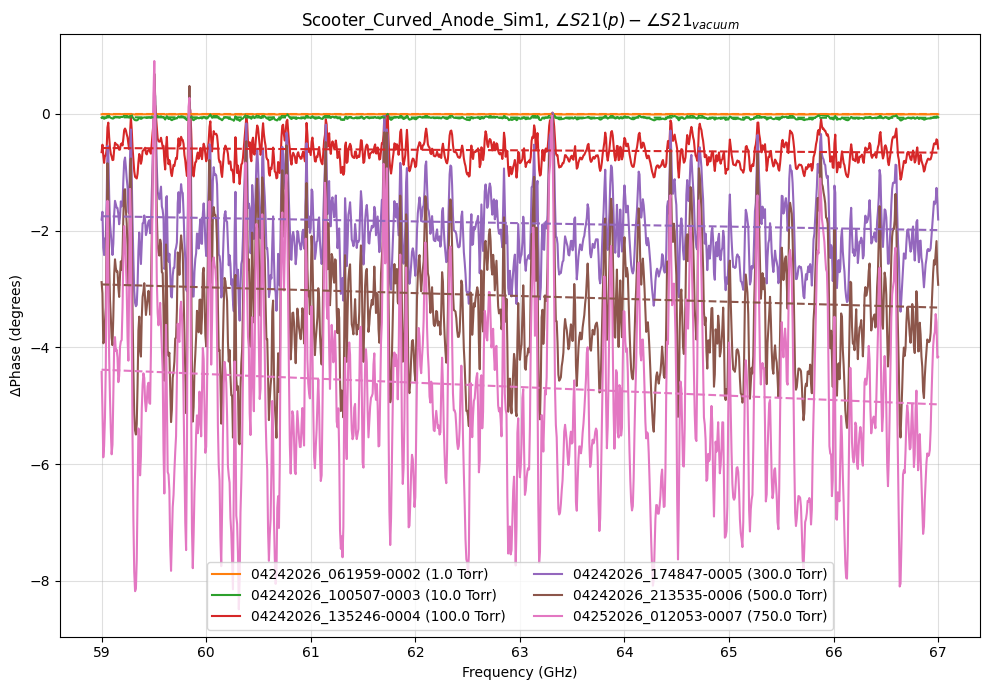

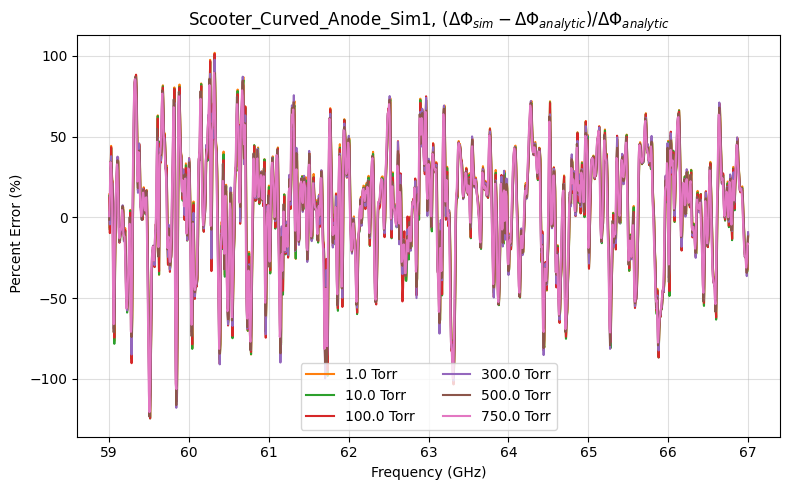

In [43]:
def get_analytic_permitivity(p, T):
    """Return (permittivity, refractive_index) of N2 at pressure p [Torr] and temperature T [K]."""
    n_N2_STP = 1.0002976          # N2 refractive index at 760 Torr, 0 °C
    n = 1 + (n_N2_STP - 1) * (p / 760) * (273.15 / T)
    return n**2, n

pressures = swept_pressures
# pressures=[0.0, 1.0, 10.0]
# colors = ['tab:blue', 'tab:orange', 'tab:green']
n_vac=1


T = 293.15          # K
c = 2.99792458e8    # m/s --speed of light
d = 0.226          # m  — path length

f_hz     = networks[0].f
lam=c/f_hz #m--MWI wavelength
freq_ghz = f_hz / 1e9

# baseline_idx    = 0
i, j            = params['S21']
phase_unwrapped = [np.unwrap(np.angle(ntwk.s[:, i, j])) * 180 / np.pi
                   for ntwk in networks]
print(baseline_idx)
baseline_phase  = phase_unwrapped[baseline_idx]

dphi_sim      = []
dphi_rad_p_T = []

# --- Phase difference: simulation vs analytic ---
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(rf'{run_name}, $\angle S21(p) - \angle S21_{{vacuum}}$')

for idx, (ntwk, phase) in enumerate(zip(networks, phase_unwrapped)):
    if idx == baseline_idx:
        continue
    dphi = phase - baseline_phase
    dphi_sim.append(dphi)
    ax.plot(freq_ghz, dphi, label=f'{ntwk.name} ({pressures[idx]} Torr)',color=colors[idx])

for k,p_torr in enumerate(pressures):
    if k == baseline_idx:
        continue
    eps, n_N2_P = get_analytic_permitivity(p_torr, T)
    dphi_a=-(n_N2_P-n_vac)*d*2*np.pi/lam*180/np.pi
    dphi_rad_p_T.append(dphi_a)
    ax.plot(freq_ghz, dphi_a, linestyle='--', color=colors[k])#label=f'{p_torr} Torr analytic',

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('ΔPhase (degrees)')
# ax.set_xlim([40,67])
ax.legend(loc='lower center',ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# --- Residual: analytic − simulation ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.set_title(rf'{run_name}, $(Δ\Phi_{{sim}}-Δ\Phi_{{analytic}})/Δ\Phi_{{analytic}}$')
for k, p_torr in enumerate(pressures):
    if k == baseline_idx:
        continue
    ax2.plot(freq_ghz, (dphi_sim[k-1]-dphi_rad_p_T[k-1])/dphi_rad_p_T[k-1] *100, label=f'{p_torr} Torr', color=colors[k])
ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel(' Percent Error (%)')
# ax2.set_ylim([-0.1,0])
# ax2.set_xlim([40,67])
# ax2.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax2.legend(loc='lower center',ncol=2)
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

1001


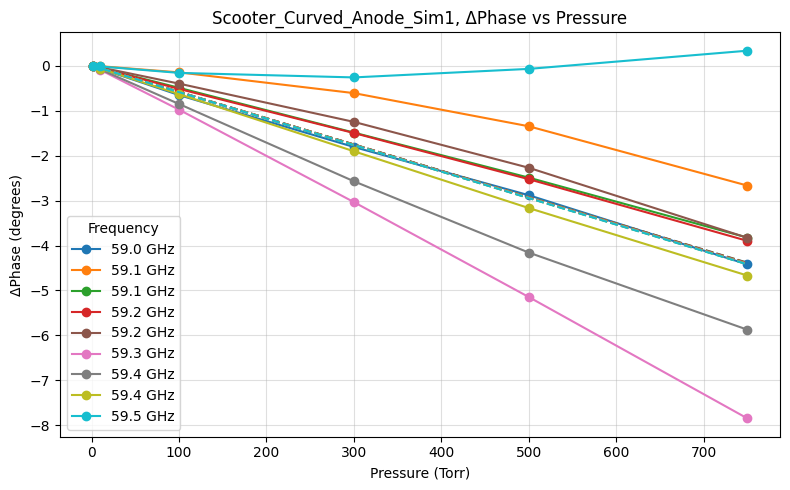

In [32]:
freq_to_plot = np.linspace(59, 59.5, 9)  # GHz
plot_colors = plt.cm.tab10(np.linspace(0, 1, len(freq_to_plot)))

non_baseline_pressures = [pressures[idx] for idx in range(len(networks)) if idx != baseline_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'{run_name}, ΔPhase vs Pressure')
print(len(freq_ghz))
for color, f_target in zip(plot_colors, freq_to_plot):
    freq_idx = np.argmin(np.abs(freq_ghz - f_target))
    dphi_at_f = [dphi_sim[k][freq_idx] for k in range(len(dphi_sim))]
    dphi_a_at_f = [dphi_rad_p_T[k][freq_idx] for k in range(len(dphi_rad_p_T))]
    ax.plot(non_baseline_pressures, dphi_at_f, color=color, marker='o',
            label=f'{freq_ghz[freq_idx]:.1f} GHz')
    ax.plot(non_baseline_pressures, dphi_a_at_f, color=color, linestyle='--')

ax.set_xlabel('Pressure (Torr)')
ax.set_ylabel('ΔPhase (degrees)')
ax.legend(title='Frequency')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()